In [1]:
import numpy as np 
import pandas as pd
import os 
import tensorflow as tf 
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt 
import seaborn as sns 
import random

In [2]:
DATA_DIR = r'P:/1-uni/machine-learning/Grapevine_Leaves_Image_Dataset'

In [3]:
# 1. Get the directory contents and filter out non-class files
content_list = os.listdir(DATA_DIR)
print(f'Initial folder contents: {content_list}')

Initial folder contents: ['Ak', 'Ala_Idris', 'Buzgulu', 'Dimnit', 'Grapevine_Leaves_Image_Dataset_Citation_Request.txt', 'Nazli']


In [4]:
# Filter out any files that are not class folders
class_names = [item for item in content_list if os.path.isdir(os.path.join(DATA_DIR, item))]
print(f'Identified class names: {class_names}')

Identified class names: ['Ak', 'Ala_Idris', 'Buzgulu', 'Dimnit', 'Nazli']


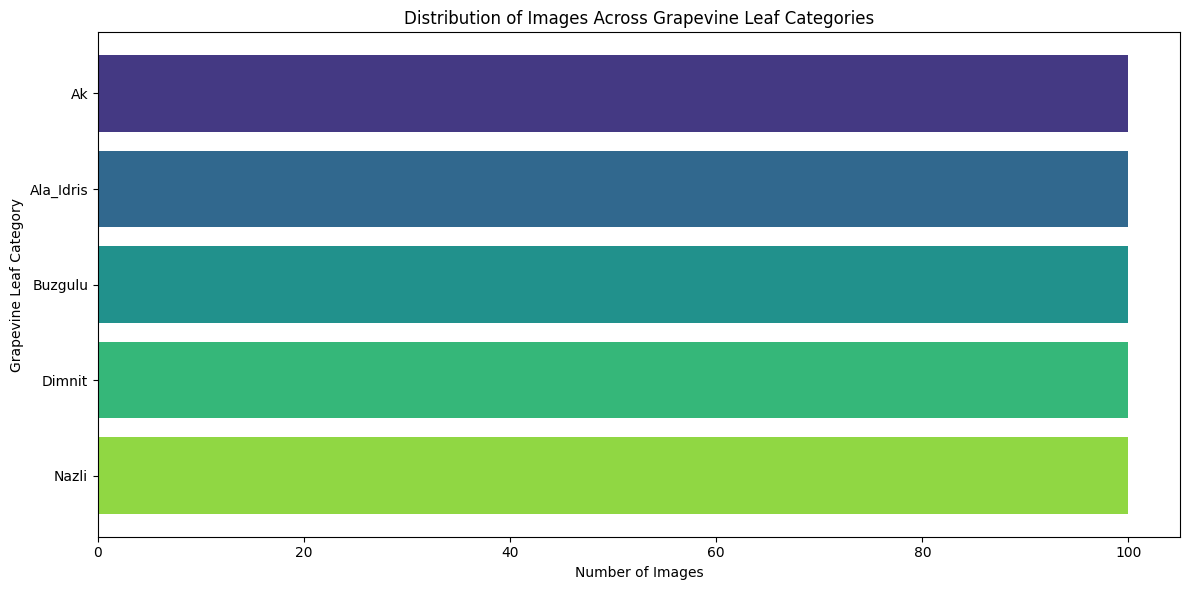

In [5]:
# 2. Count images in each class directory
image_counts = {}
for class_name in class_names:
    class_path = os.path.join(DATA_DIR, class_name)
    image_files = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]
    image_counts[class_name] = len(image_files)

# 3. Create a Pandas DataFrame for easier plotting
data_frame = pd.DataFrame(list(image_counts.items()), columns=['Category', 'Image Count'])

# 4. Generate a horizontal bar chart using matplotlib
plt.figure(figsize=(12, 6), dpi=100)
plt.barh(data_frame['Category'], data_frame['Image Count'], color=sns.color_palette("viridis", len(class_names)))
plt.xlabel("Number of Images")
plt.ylabel("Grapevine Leaf Category")
plt.title("Distribution of Images Across Grapevine Leaf Categories")
plt.gca().invert_yaxis()  # Invert y-axis to show categories from top to bottom
plt.tight_layout()
plt.show()

In [6]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

def display_images(DATA_DIR, class_names, content_list):
    """
    Displays 4 random images from each subdirectory in DATA_DIR.

    Parameters(args):
        DATA_DIR (str): The root directory containing subdirectories of images.
        class_names (list): A list of class names (subdirectory names).
        content_list (list): A list of all files and folders inside DATA_DIR.

    Returns:
        None: Displays the images in a matplotlib figure.
    """
    for class_name in class_names:
        class_dir = os.path.join(DATA_DIR, class_name)
        if not os.path.isdir(class_dir):
            print(f"Skipping {class_name} as it's not a directory.")
            continue
        
        # all image filenames in the subdirectory
        image_files = [f for f in os.listdir(class_dir) if os.path.isfile(os.path.join(class_dir, f))]
        
        num_images_to_display = min(4, len(image_files))
        
        if num_images_to_display == 0:
            print(f"No images found in {class_name}. Skipping...")
            continue
        
        # Randomly choose 4 images
        selected_images = random.sample(image_files, num_images_to_display)
        
        # figure of  the class
        plt.figure(figsize=(15, 5))
        plt.suptitle(f"Class: {class_name}", fontsize=16)
        
        for idx, image_name in enumerate(selected_images):
            image_path = os.path.join(class_dir, image_name)
            img = mpimg.imread(image_path)
        
            plt.subplot(1, num_images_to_display, idx + 1)
            plt.imshow(img)
            plt.axis('off')
            plt.title(image_name, fontsize=10)
        
        plt.tight_layout()
        plt.show()

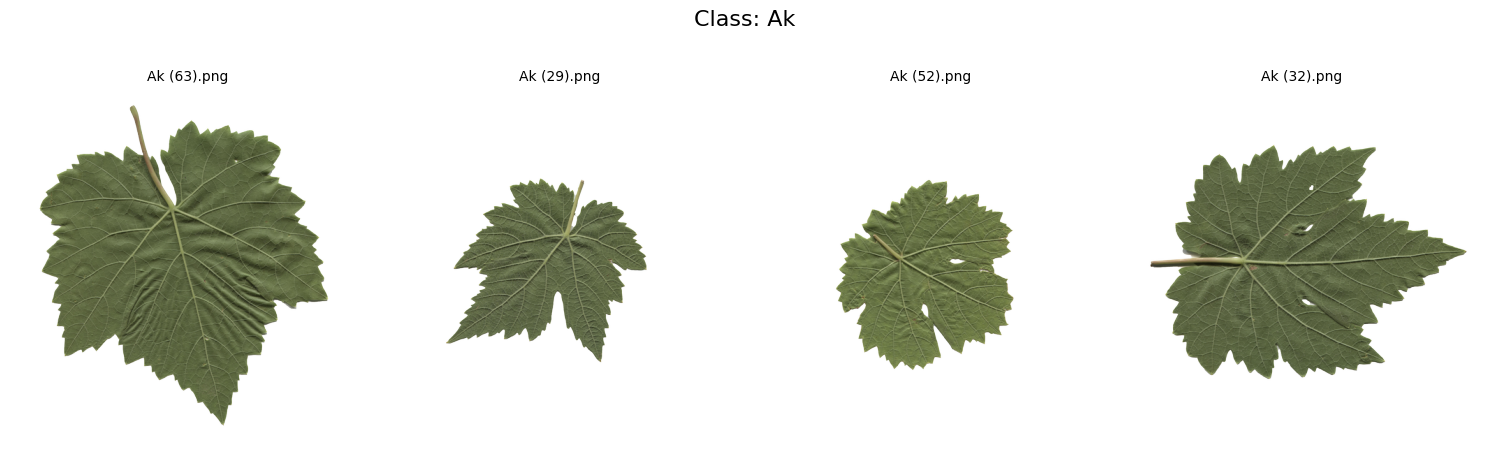

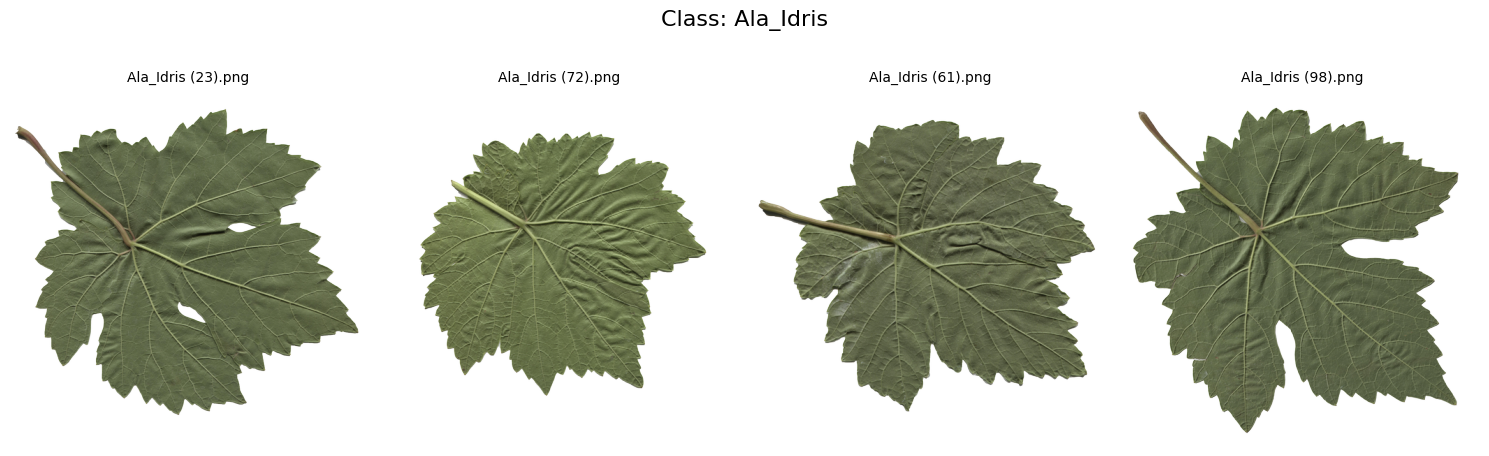

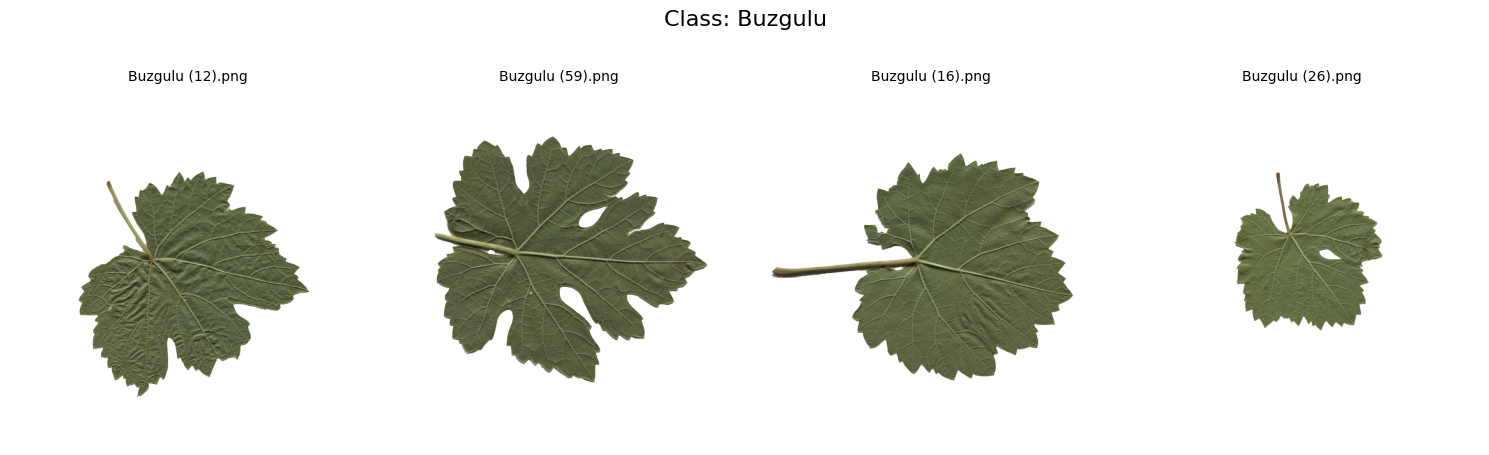

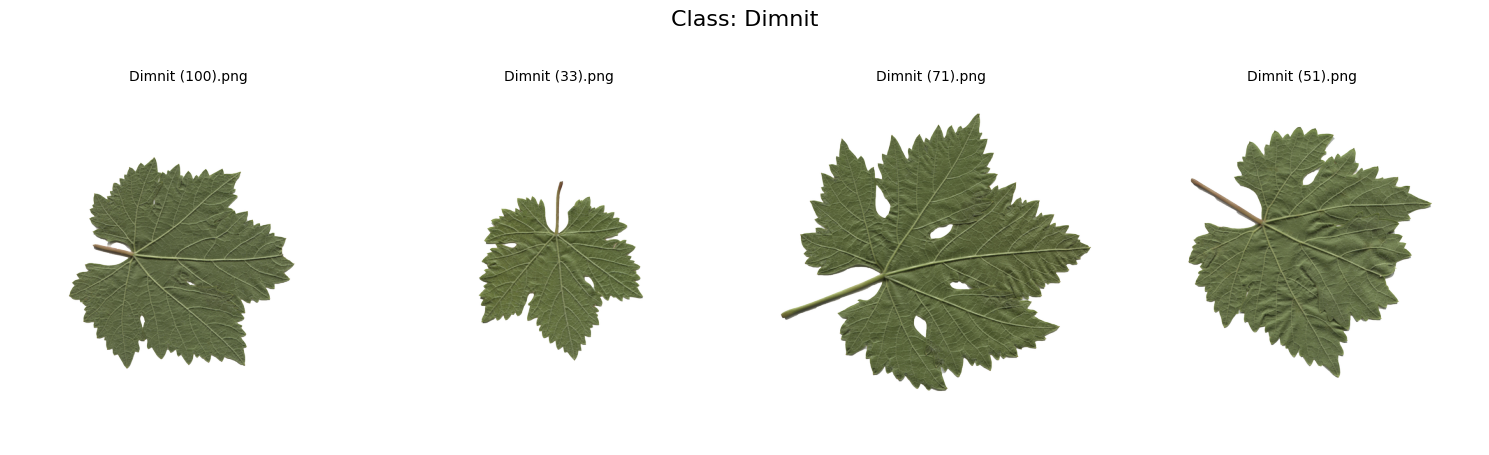

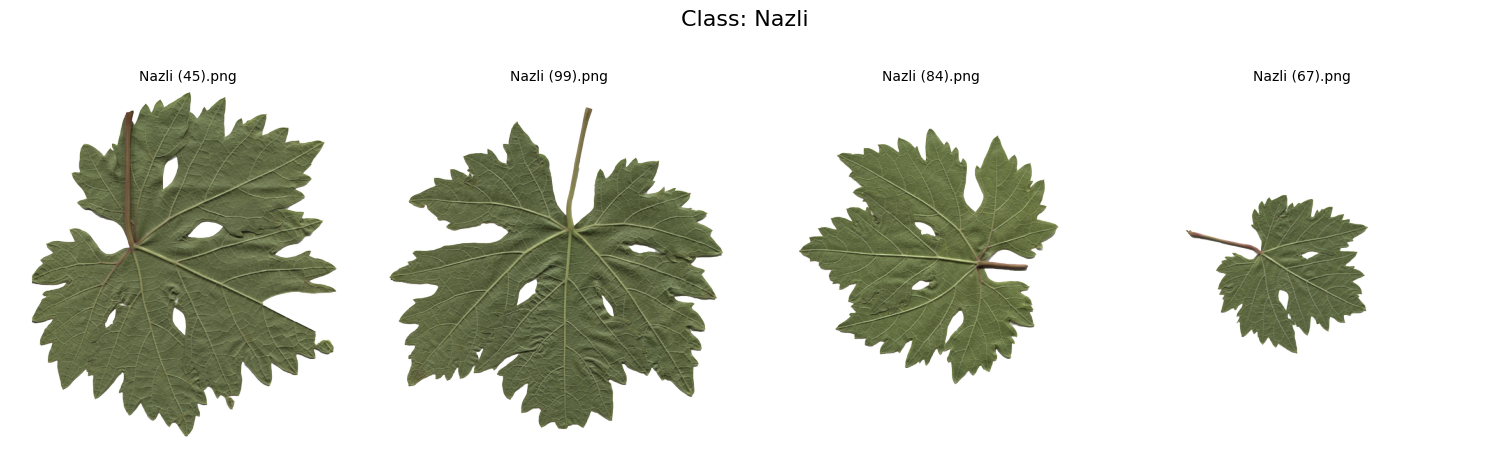

In [7]:
display_images(DATA_DIR, class_names, content_list)

In [8]:
def split_data(dir_data, image_size, label_model='binary', batch_size=32, percentage_val_data=0.15, percentage_test_data=0.15):
    """
    Split the dataset into training, validation, and testing sets.

    Args:
        dir_data (str): Path to the dataset directory.
        image_size (tuple): Image dimensions (height, width).
        label_model (str): Label mode ('binary', 'categorical', or None).
        batch_size (int): Number of samples per batch.
        percentage_val_data (float): Percentage of data for validation.
        percentage_test_data (float): Percentage of data for testing.

    Returns:
        train_dataset, val_dataset, test_dataset: Datasets for training, validation, and testing.
    """
    # Calculate the total percentage for validation + test split
    total_split = percentage_val_data + percentage_test_data

    # Ensure that the combined split is less than 1.0
    if total_split >= 1.0:
        raise ValueError("The combined percentages for validation and test data must be less than 1.0.")

    # Load the training dataset with the remaining data after the validation and test split
    training_dataset = tf.keras.utils.image_dataset_from_directory(
        directory=dir_data,
        label_mode=label_model,
        color_mode='rgb',
        batch_size=batch_size,
        image_size=image_size,
        shuffle=True,
        seed=101,
        validation_split=total_split,  # The total split for validation and test
        subset='training',  # Use this subset for training
    )

    # Load the temporary dataset for validation + test
    temp_dataset = tf.keras.utils.image_dataset_from_directory(
        directory=dir_data,
        label_mode=label_model,
        color_mode='rgb',
        batch_size=batch_size,
        image_size=image_size,
        shuffle=True,
        seed=101,
        validation_split=total_split,  # The total split for validation and test
        subset='validation',  # Use this subset for validation + test
    )

    # Calculate how many batches are in the temporary dataset
    total_temp_batches = tf.data.experimental.cardinality(temp_dataset).numpy()
    
    # Determine how many batches should go to validation
    val_batches = int(total_temp_batches * (percentage_val_data / total_split))
    
    # Remaining batches will be used for testing
    test_batches = total_temp_batches - val_batches

    # Split the temp_dataset into validation and test datasets
    val_dataset = temp_dataset.take(val_batches)
    test_dataset = temp_dataset.skip(val_batches)

    # Optimize the datasets with caching and prefetching
    training_dataset = training_dataset.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
    val_dataset = val_dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
    test_dataset = test_dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

    return training_dataset, val_dataset, test_dataset

In [9]:
training_data , validation_data, testing_data = split_data(DATA_DIR,(224,224),'categorical',32,0.2)

Found 500 files belonging to 5 classes.
Using 325 files for training.
Found 500 files belonging to 5 classes.
Using 175 files for validation.


In [10]:
for images, labels in training_data.take(1):
    example_batch_images = images
    example_batch_labels = labels

print(f"Maximum pixel value of images: {np.max(example_batch_images.numpy())}\n")
print(f"Shape of batch of images: {example_batch_images.shape}")
print(f"Shape of batch of labels: {example_batch_labels.shape}")

Maximum pixel value of images: 255.0

Shape of batch of images: (32, 224, 224, 3)
Shape of batch of labels: (32, 5)


In [22]:
def data_augmentation():
    data_aug = tf.keras.Sequential([
        tf.keras.layers.RandomFlip("vertical"),
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.2),
        tf.keras.layers.RandomZoom(0.2, fill_mode='nearest'),
        tf.keras.layers.RandomContrast(0.2),
        tf.keras.layers.RandomTranslation(0.1, 0.1),
        tf.keras.layers.RandomBrightness(0.2), 
        tf.keras.layers.GaussianNoise(0.1)
    ])
    return data_aug

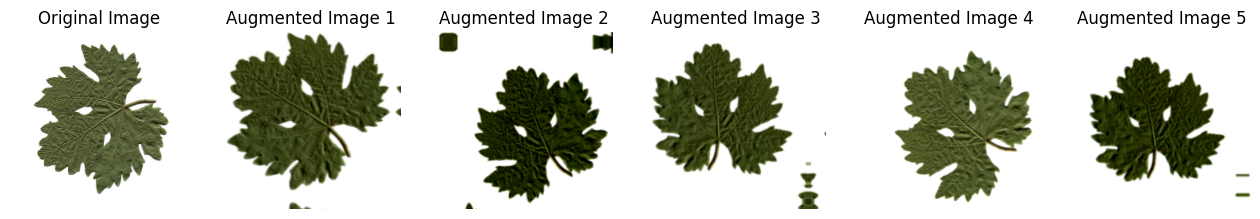

In [23]:
# Apply data augmentation and visualize the results

augmentor = data_augmentation()  # Create the data augmentation object

# Select a sample image from the batch
sample_img = tf.keras.utils.array_to_img(example_batch_images[2])

# List to store the original and augmented images
augmented_images = [sample_img]

# Apply random augmentations 10 times
for _ in range(5):  # 5 times to match the number of subplots
    # Expand dimensions for augmentation, then apply augmentation
    augmented_img = augmentor(tf.expand_dims(sample_img, axis=0))
    
    # Remove extra dimensions and convert back to an image
    augmented_img = tf.keras.utils.array_to_img(tf.squeeze(augmented_img))
    
    # Add the augmented image to the list
    augmented_images.append(augmented_img)

# Plot the original and augmented images
fig, axes = plt.subplots(1, 6, figsize=(16, 7))

# Titles for the images
titles = ['Original Image', 'Augmented Image 1', 'Augmented Image 2', 
          'Augmented Image 3', 'Augmented Image 4', 'Augmented Image 5']

# Display each image with its title
for ax, img, title in zip(axes, augmented_images, titles):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')  # Hide the axis labels

# Show the plot
plt.show()

In [24]:
def features_extractor_vgg19(input_images_size, name_last_layer, fine_tune_at=18):
    # Load the pre-trained VGG-19 model without the top classification layer
    pre_trained_vgg19 = tf.keras.applications.VGG19(
        input_shape=input_images_size,
        include_top=False,  # Exclude the top classification layer
        weights='imagenet'  # Use weights trained on ImageNet
    )

    # Unfreeze the entire model for fine-tuning
    pre_trained_vgg19.trainable = True

    # Freeze the layers up to the `fine_tune_at` layer
    for layer in pre_trained_vgg19.layers[:fine_tune_at]:
        layer.trainable = False

    # Get the output of the specified layer for feature extraction
    last_layer = pre_trained_vgg19.get_layer(name_last_layer)
    last_output = last_layer.output

    return pre_trained_vgg19, last_output

In [25]:
def classifier(input):
    # Global pooling to reduce dimensions
    x = tf.keras.layers.GlobalAveragePooling2D()(input)
    x = tf.keras.layers.Flatten()(x)
    
    # Fully connected layers with batch normalization
    x = tf.keras.layers.Dense(512, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    
    # Dropout for regularization
    x = tf.keras.layers.Dropout(0.4)(x)
    
    # Output layer for 5 classes with softmax activation
    x = tf.keras.layers.Dense(5, activation='softmax')(x)  
    return x

In [26]:
def final_model(input_images_size, name_last_layer, fine_tune_at=18):
    # Define the input shape
    inputs = tf.keras.Input(shape=input_images_size)

    # Apply data augmentation
    augmented_inputs = data_augmentation()(inputs)

    # Extract features using the pre-trained VGG-19 model
    pre_trained_model, output = features_extractor_vgg19(input_images_size, name_last_layer, fine_tune_at)

    # Pass the augmented input through the pre-trained model
    features = pre_trained_model(augmented_inputs, training=False)

    # classifier head
    x = classifier(features)

    # complete model
    model = tf.keras.Model(inputs, x)

    # Compile the model with a lower learning rate to avoid overfitting
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.00005,  # Smaller learning rate for fine-tuning
            beta_1=0.9,
            beta_2=0.999,
            epsilon=1e-08
        ),
        loss=tf.keras.losses.CategoricalCrossentropy(),
        metrics=['accuracy']
    )

    return model

In [27]:
# Constants for input image size and the name of the last layer for feature extraction
INPUT_IMAGE_SIZE = (224, 224, 3)
NAME_LAST_LAYER = 'block4_pool'  # Use an intermediate layer

In [28]:
# Build the final model
model = final_model(INPUT_IMAGE_SIZE, NAME_LAST_LAYER, fine_tune_at=18)

In [32]:
model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_4 (Sequential)            │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ vgg19 (Functional)                   │ (None, 7, 7, 512)           │      20,024,384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 512)                 │         262,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 20,455,493 (78.03 MB)

 Trainable params: 7,508,741 (28.64 MB)

 Non-trainable params: 12,946,752 (49.39 MB)

In [33]:
# the early stopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)

In [34]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',    # Monitor the validation loss
    factor=0.1,            # Reduce the learning rate by a factor of 0.1 (i.e., multiply by 0.1)
    patience=3,            # If val_loss doesn't improve for 3 epochs, reduce the learning rate
    min_lr=1e-10           # Don't let the learning rate go below this value
)

In [35]:
# Train the model
history = model.fit(
    training_data,     # Training dataset
    validation_data=validation_data,    # Validation dataset
    epochs=50,                   # Max number of epochs
    callbacks=[early_stopping, reduce_lr],  # Add both callbacks here
    #batch_size=32              
)

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 120s 11s/step - accuracy: 0.2525 - loss: 2.4324 - val_accuracy: 0.1354 - val_loss: 4.6645 - learning_rate: 5.0000e-05
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 107s 10s/step - accuracy: 0.2316 - loss: 2.2211 - val_accuracy: 0.1458 - val_loss: 3.6782 - learning_rate: 5.0000e-05
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 114s 11s/step - accuracy: 0.2788 - loss: 2.2317 - val_accuracy: 0.1458 - val_loss: 4.7299 - learning_rate: 5.0000e-05
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 108s 10s/step - accuracy: 0.3964 - loss: 1.7773 - val_accuracy: 0.1458 - val_loss: 4.2339 - learning_rate: 5.0000e-05
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 105s 10s/step - accuracy: 0.4251 - loss: 1.7118 - val_accuracy: 0.1354 - val_loss: 5.0665 - learning_rate: 5.0000e-05
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 99s 9s/step - accuracy: 0.4540 - loss: 1.4013 - val_accuracy: 0.1354 - val_loss: 4.4616 - learning_rate: 5.0000e-06
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 98s 9s/step - accuracy: 0.43